# Cross-species splice-usage comparison via whole-genome alignment (multiz)

Like [splice_cross_species_alignment_sites.ipynb](splice_cross_species_alignment_sites.ipynb), but instead
of exon-level splice-site orthology, sites are matched across species with the **multiz100way
whole-genome alignment** (`*.maf.gz`).

## Pipeline
1. **Human sites** — all splice sites in the prediction data on human **chr8**.
2. **Alignment lift-over** — for each human site, read the aligned coordinate in each other
   species directly from the MAF (`hg38.chr8` ↔ mm10 / rn6 / oryCun2 / monDom5).
3. **Match to predictions** — snap each aligned coordinate to the nearest predicted site in that
   species (within `ALIGN_TOL` bp).
4. **Compare** — developmental **dynamics** (role: dynamic / flat) and **prediction accuracy**
   (Pearson r, RMSE) of the human site vs its aligned counterpart in each species.

## Setup

In [1]:
import os
import subprocess
import bisect
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import pearsonr

from alphagenome_pytorch.plotting.splicing import (
    TISSUE_COLORS,
    TISSUE_ORDER,
    SPECIES_SCI,
)
from alphagenome_pytorch.clustering import (
    classify_cluster_shape,
    SHAPE_ORDER,
)
plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

In [5]:
# ── Config ────────────────────────────────────────────────────────────────────
HOME = os.path.expanduser("~")
DATA_DIR   = f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data"
USAGE_TMPL = os.path.join(DATA_DIR, "combined_usage_data_{species}.parquet")

MODEL      = "lora_32_human_mouse_rat_rabbit_opossum"
PRED_DIR   = os.path.join(f"{HOME}/sds/sd17d003/Anamaria/alphagenome_genomicsxai",
                          MODEL, "preds_all_intersect_protein_coding")

CHROMS     = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15"]

# species -> UCSC assembly name used in the multiz MAF
ASSEMBLY = {"mouse": "mm10", "rat": "rn6", "rabbit": "oryCun2", "opossum": "monDom5"}
OTHER_SPECIES = ["mouse", "rat", "rabbit", "opossum"]
# The MAF has rat as rn6, but the rat prediction data is on rn5, so rat aligned
# coordinates are lifted rn6 -> rn5 with a UCSC chain file (set RAT_CHAIN, or None to skip).
RAT_CHAIN = f"{HOME}/sds/sd17d003/Anamaria/genomes/chains/rn6ToRn5.over.chain.gz"

FOCUS_TISSUE   = "Brain"
ALIGN_TOL      = 3      # bp: snap an aligned coordinate to the nearest predicted site
MIN_TIMEPOINTS = 6
AMP_DYNAMIC    = 0.50
AMP_FLAT       = 0.50
R_WELL_PRED    = 0.90
MAE_WELL_PRED  = 0.10

DYNAMIC_SHAPES = {"up_early", "up_late", "up_mid",
                  "down_early", "down_late", "down_mid", "up-down", "down-up"}
FLAT_SHAPES    = {"flat_low", "flat_mid_low", "flat_mid", "flat_mid_high", "flat_high"}

OUT_DIR = os.path.join(PRED_DIR, "human", "cross_species_alignment")
os.makedirs(OUT_DIR, exist_ok=True)

# per-chromosome MAF / reference prefix / lift-over cache
def maf_path(c):       return f"{HOME}/sds/sd17d003/Anamaria/genomes/multiz100way/chr{c}.maf.gz"
def ref_prefix(c):     return f"hg38.chr{c}"
def liftover_cache(c): return os.path.join(OUT_DIR, f"liftover_chr{c}.parquet")
CHROM_TAG = "_".join(CHROMS)

def _pred_path(sp): return os.path.join(PRED_DIR, sp, f"usage_{sp}.parquet")
def _pred_npz(sp):  return os.path.join(PRED_DIR, sp, f"usage_{sp}.npz")

DATA_CONFIG = os.path.join(DATA_DIR, "data_config.json")

def ensure_pred_parquet(sp):
    """Build usage_{sp}.parquet from usage_{sp}.npz (+ data_config condition labels) if the
    parquet is missing but the npz exists. Returns 'parquet' / 'converted' / 'missing'."""
    if os.path.exists(_pred_path(sp)):
        return "parquet"
    if not os.path.exists(_pred_npz(sp)):
        return "missing"
    with open(DATA_CONFIG) as f:
        data_config = json.load(f)
    d = np.load(_pred_npz(sp))
    df = pd.DataFrame({"chr_pos": d["chr_pos"], "cond_ids": d["cond_ids"],
                       "SSE_pred": d["pred"], "SSE_true": d["true"]})
    df["Species"]    = sp
    df["Chromosome"] = df["chr_pos"].apply(lambda x: x.split(":")[0])
    df["Position"]   = df["chr_pos"].apply(lambda x: int(x.split(":")[1]))
    idx_to_name = {v: k for k, v in data_config[sp]["condition_labels"].items()}
    df["Condition_Name"] = df["cond_ids"].map(idx_to_name)
    raw = df["Condition_Name"].fillna("None_0").to_numpy()
    df["Tissue"]    = [s.split("_")[0] for s in raw]
    df["Timepoint"] = [int(s.split("_")[1]) for s in raw]
    df = df[["Species", "Chromosome", "Position", "SSE_true", "SSE_pred",
             "Condition_Name", "Tissue", "Timepoint"]]
    os.makedirs(os.path.dirname(_pred_path(sp)), exist_ok=True)
    df.to_parquet(_pred_path(sp), index=False)
    return "converted"

for c in CHROMS:
    print(f"chr{c} MAF:", maf_path(c), "| exists:", os.path.exists(maf_path(c)))
for sp in ["human"] + OTHER_SPECIES:
    status = ensure_pred_parquet(sp)
    tag = {"parquet": "OK  ", "converted": "CONV", "missing": "MISS"}[status]
    note = " (npz -> parquet)" if status == "converted" else ""
    print(f"{tag}  {sp} predictions{note}")

chr1 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr1.maf.gz | exists: True
chr2 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr2.maf.gz | exists: True
chr3 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr3.maf.gz | exists: True
chr4 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr4.maf.gz | exists: True
chr5 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr5.maf.gz | exists: True
chr6 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr6.maf.gz | exists: True
chr7 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr7.maf.gz | exists: True
chr8 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr8.maf.gz | exists: True
chr9 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr9.maf.gz | exists: True
chr10 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr10.maf.gz | exists: True
chr11 MAF: /Users/elek/sds/sd17d003/Anamaria/genomes/multiz100way/chr11.maf.gz

## Helpers

In [3]:
from alphagenome_pytorch import xspecies as sx

# Shared helpers live in alphagenome_pytorch.xspecies; thin wrappers bind this
# notebook's config so the rest of the notebook keeps the same names/signatures
# (and the same helpers are reused by splice_cross_species_usage.ipynb).
TPS = sx.TPS

def load_focus_usage(sp, tissue, positions=None):
    return sx.load_focus_usage(USAGE_TMPL, sp, tissue, positions)

def trajectory_stats(df):
    return sx.trajectory_stats(df)

def classify_traj(vec):
    return sx.classify_traj(vec, MIN_TIMEPOINTS)

def is_dynamic_shape(s):
    return sx.is_dynamic_shape(s)

def role(shape, amplitude):
    return sx.role(shape, amplitude, DYNAMIC_SHAPES, FLAT_SHAPES, AMP_DYNAMIC, AMP_FLAT)

def xcorr(a, b):
    return sx.xcorr(a, b)

def load_predictions(sp, tissue, positions=None):
    p = sx.load_predictions(PRED_DIR, DATA_DIR, SPECIES_SCI, sp, tissue, positions)
    return sx.attach_strand(p, USAGE_TMPL, sp)   # add Strand -> site ids carry strand

def pred_site_metrics(pred_df):
    return sx.pred_site_metrics(pred_df)

def is_well_predicted(pred_r, pred_rmse, true_dynamic):
    return sx.is_well_predicted(pred_r, pred_rmse, true_dynamic, R_WELL_PRED, MAE_WELL_PRED)


# ── Cluster/shape labels from the precomputed prediction-cluster parquets ─────────
FLAT_SHAPES_SET = set(FLAT_SHAPES)

def shape_role(shape):
    """Broad developmental role from a cluster shape label: 'flat' / 'dynamic' / 'complex' / None."""
    if shape is None or (isinstance(shape, float) and np.isnan(shape)):
        return None
    if shape in FLAT_SHAPES_SET:
        return "flat"
    if shape == "complex":
        return "complex"
    return "dynamic"          # up_*, down_*, up-down, down-up

def shape_parquet_path(sp, tissue=None, split="test"):
    tissue = tissue or FOCUS_TISSUE
    tdir = tissue.replace(" ", "_")
    return os.path.join(PRED_DIR, sp, "pred_gp_splice_usage", tdir,
                        f"{sp}_{tdir}_{split}_prediction_clusters.parquet")

_shape_cache = {}
def load_shapes(sp, tissue=None):
    """Prediction-cluster labels for a species/tissue, indexed by chrom:pos:strand site id
    (obs_shape / ref_shape / pred_shape / same_shape / n_obs). None if the parquet is missing."""
    tissue = tissue or FOCUS_TISSUE
    key = (sp, tissue)
    if key not in _shape_cache:
        pth = shape_parquet_path(sp, tissue)
        if not os.path.exists(pth):
            _shape_cache[key] = None
        else:
            d = pd.read_parquet(pth)
            d["Chromosome"] = d["Chromosome"].astype(str)
            d["site"] = [sx.make_site(c, pos, st)
                         for c, pos, st in zip(d["Chromosome"], d["Position"], d["Strand"])]
            _shape_cache[key] = d[~d.duplicated("site")].set_index("site")
    return _shape_cache[key]


CAT_ORDER = ["up", "down", "flat", "biphasic", "complex"]
def broad_cat(shape):
    """Finer directional category of a cluster shape: up / down / flat / biphasic / complex."""
    if shape is None or (isinstance(shape, float) and pd.isna(shape)):
        return None
    if shape.startswith("up_"):        return "up"
    if shape.startswith("down_"):      return "down"
    if shape.startswith("flat"):       return "flat"
    if shape in ("up-down", "down-up"): return "biphasic"
    return "complex"

## 1 — Human sites (observed cluster shapes)

Instead of classifying trajectories on the fly, each human site is joined to its **precomputed
cluster-shape** labels from `scripts/cluster_predictions.py`
(`<species>/pred_gp_splice_usage/<Tissue>/..._prediction_clusters.parquet`). The developmental
**role** (dynamic / flat / complex) comes from the *observed* shape (`obs_shape`), and
`same_shape` (predicted shape == observed shape) is the "well-predicted" flag.

In [4]:
# Human sites + observed/predicted cluster-shape labels (precomputed, joined - no on-the-fly role())
hsh = load_shapes("human")
if hsh is None:
    raise FileNotFoundError(f"No human prediction-cluster parquet: {shape_parquet_path('human')}\n"
                            f"Run scripts/cluster_predictions.py first.")
human = hsh.reset_index()
human = human[human["Chromosome"].isin(CHROMS) & (human["n_obs"] >= MIN_TIMEPOINTS)].copy()
human["role"]  = human["obs_shape"].map(shape_role)      # dynamic / flat / complex from OBSERVED shape
human["shape"] = human["obs_shape"]                      # (kept name for downstream convenience)

print(f"Human chr{CHROM_TAG} {FOCUS_TISSUE}: {len(human):,} clustered sites")
print("observed roles:", human["role"].value_counts(dropna=False).to_dict())
print(f"well-predicted (pred_shape == obs_shape): {human['same_shape'].mean():.3f}")
human[["Chromosome","Position","Strand","obs_shape","pred_shape","same_shape","role"]].head()

Human chr1_2_3_4_5_6_7_8_9_10_11_12_13 Brain: 9,917 clustered sites
observed roles: {'flat': 7454, 'dynamic': 1396, 'complex': 1067}
well-predicted (pred_shape == obs_shape): 0.248


,Chromosome,Position,Strand,obs_shape,pred_shape,same_shape,role
0,1,1535506,-,complex,up_early,False,complex
1,1,1535588,-,complex,up_early,False,complex
2,1,1535796,-,up_early,up_early,True,dynamic
3,1,1539683,-,up_early,up_early,True,dynamic
4,1,1539789,-,up_early,up_early,True,dynamic


## 2 — Lift over to other species via the multiz alignment

Stream the MAF once; for each human site read the aligned coordinate in each target assembly.
Cached to parquet so it's only parsed once. (Streaming the 3.5 GB file takes a few minutes.)

In [5]:
# The multiz MAF whole-genome-alignment lift-over lives in the shared module.
maf_liftover = sx.maf_liftover

In [6]:
# -- Load cached lift-over or parse MAF, per chromosome --
# Each chromosome has its own cache of raw assembly-native coordinates (tissue-independent).
def all_ref_positions(c):
    """All human chr{c} predicted-site positions, independent of tissue."""
    ppath = _pred_path("human")
    if os.path.exists(ppath):
        s = pd.read_parquet(ppath, columns=["Chromosome", "Position"]).drop_duplicates()
        s = s[s["Chromosome"].astype(str) == c]
        return sorted(s["Position"].astype(int).unique().tolist())
    d = np.load(_pred_npz("human"))
    cp = np.asarray(d["chr_pos"]).astype(str)
    ch = np.array([x.split(":")[0] for x in cp]); po = np.array([int(x.split(":")[1]) for x in cp])
    return sorted(np.unique(po[ch == c]).tolist())

asm2sp = {a: s for s, a in ASSEMBLY.items()}
parts, n_positions = [], 0
for c in CHROMS:
    positions = all_ref_positions(c)
    n_positions += len(positions)
    cache = liftover_cache(c)
    if os.path.exists(cache):
        part = pd.read_parquet(cache)
        print(f"chr{c}: loaded cache ({len(part):,} rows) for {len(positions):,} predicted sites")
    else:
        print(f"chr{c}: parsing MAF for {len(positions):,} human sites ...")
        res = maf_liftover(maf_path(c), ref_prefix(c), positions, set(ASSEMBLY.values()))
        rows = []
        for hpos, d in res.items():
            for asm, (tchrom, tpos, tstrand) in d.items():
                rows.append(dict(human_site=f"{c}:{hpos}", species=asm2sp[asm],
                                 assembly=asm, aln_chrom=str(tchrom), aln_pos=int(tpos),
                                 aln_strand=tstrand))
        part = pd.DataFrame(rows)
        part.to_parquet(cache, index=False)
        print(f"chr{c}: saved lift-over -> {cache}")
    parts.append(part)
    
lift_df = pd.concat(parts, ignore_index=True)

# ── Rat: lift MAF coordinates rn6 -> rn5 (the assembly of the rat prediction data) ──
# The caches store raw assembly-native (rn6) coordinates; the chain conversion is applied
# here on load so it stays reproducible if the chain changes.
if RAT_CHAIN and os.path.exists(RAT_CHAIN) and (lift_df["species"] == "rat").any():
    from pyliftover import LiftOver
    _lo = LiftOver(RAT_CHAIN)
    mask = lift_df["species"] == "rat"
    n_before = int(mask.sum())
    new_chrom, new_pos = [], []
    for _, r in lift_df[mask].iterrows():
        conv = _lo.convert_coordinate("chr" + str(r["aln_chrom"]), int(r["aln_pos"]))
        if conv:
            cc, pos = conv[0][0], conv[0][1]
            new_chrom.append(cc.removeprefix("chr")); new_pos.append(int(pos))
        else:
            new_chrom.append(None); new_pos.append(np.nan)
    lift_df.loc[mask, "aln_chrom"] = new_chrom
    lift_df.loc[mask, "aln_pos"]   = new_pos
    lift_df.loc[mask, "assembly"]  = "rn6->rn5"
    lift_df = lift_df[lift_df["aln_pos"].notna()].copy()
    lift_df["aln_pos"] = lift_df["aln_pos"].astype(int)
    print(f"rat rn6->rn5 chain lift: {int((lift_df['species']=='rat').sum()):,}/{n_before:,} lifted")
elif (lift_df["species"] == "rat").any() and not (RAT_CHAIN and os.path.exists(RAT_CHAIN)):
    print("rat: RAT_CHAIN not available — rat coordinates left as rn6 (may not match rn5 predictions)")

# canonicalise human_site to chrom:pos:strand (upgrades legacy strand-less caches)
h_strand = sx.strand_series(USAGE_TMPL, "human")
lift_df["human_site"] = lift_df["human_site"].map(lambda s: sx.ensure_site_strand(s, h_strand))

print(f"Aligned mappings: {len(lift_df):,}")
print("per species:", lift_df["species"].value_counts().to_dict())
print(f"human chr{CHROM_TAG} sites with >=1 alignment: {lift_df['human_site'].nunique():,} / {n_positions:,}")
lift_df.head()

chr1: loaded cache (21,446 rows) for 5,996 predicted sites
chr2: loaded cache (16,649 rows) for 4,733 predicted sites
chr3: loaded cache (11,229 rows) for 3,175 predicted sites
chr4: loaded cache (5,482 rows) for 1,607 predicted sites
chr5: loaded cache (9,040 rows) for 2,561 predicted sites
chr6: loaded cache (8,611 rows) for 2,407 predicted sites
chr7: loaded cache (8,788 rows) for 2,534 predicted sites
chr8: loaded cache (5,394 rows) for 1,621 predicted sites
chr9: loaded cache (8,930 rows) for 2,602 predicted sites
chr10: loaded cache (7,185 rows) for 1,953 predicted sites
chr11: loaded cache (12,671 rows) for 3,721 predicted sites
chr12: loaded cache (10,363 rows) for 3,103 predicted sites
chr13: loaded cache (3,073 rows) for 881 predicted sites


/tmp/ipykernel_568512/3188314104.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[177118838, 177118602, 177118477, 177118006, 177115730, 176664385, 176664311, 176664103, 176660033, 176659927, 176659655, 176002564, 176002214, 176000135, 176000092, 175986567, 175986488, 175986485, 175986382, 175986249, 175971041, 175968906, 175968734, 175968255, 175968132, 175960446, 175960336, 175959634, 175959538, 175951476, 175951389, 175951300, 175950689, 175950599, 175949504, 175949394, 175947996, 175947898, 175945969, 175945898, 175945132, 175839833, 175839152, 175839084, 175838950, 175838850, 175838343, 175838273, 175838239, 175837745, 175837696, 175837520, 175837465, 175836696, 175836545, 175836010, 175835923, 175835715, 175835603, 175834053, 175833898, 175831784, 175831684, 175831417, 175831336, 175830807, 175830626, 175830283, 175830133, 175830130, 175829745, 175829653, 175829461, 175829351, 175829278, 17582

rat rn6->rn5 chain lift: 32,959/33,137 lifted
Aligned mappings: 128,683
per species: {'mouse': 33390, 'rat': 32959, 'rabbit': 31900, 'opossum': 30434}
human chr1_2_3_4_5_6_7_8_9_10_11_12_13 sites with >=1 alignment: 35,205 / 36,894


,human_site,species,assembly,aln_chrom,aln_pos,aln_strand
0,1:976268:-,mouse,mm10,4,156220109,-
1,1:976268:-,rat,rn6->rn5,5,177118838,-
2,1:976268:-,rabbit,oryCun2,Un1042,30245,-
3,1:976268:-,opossum,monDom5,Un,42575058,+
4,1:976498:-,mouse,mm10,4,156219865,-


## 3 — Match aligned coordinates to clustered sites (other species)

For each other species, the human-aligned coordinate is snapped (within `ALIGN_TOL`) to the
nearest **clustered** site in that species' prediction-cluster parquet, and its observed/predicted
shape labels are recorded. No trajectories are re-classified here — everything comes from the
precomputed shapes.

In [7]:
def _nearest(sorted_pos, pos, tol):
    if len(sorted_pos) == 0: return None
    j = bisect.bisect_left(sorted_pos, pos)
    cand = [sorted_pos[k] for k in (j - 1, j) if 0 <= k < len(sorted_pos)]
    if not cand: return None
    best = min(cand, key=lambda x: abs(x - pos))
    return int(best) if abs(best - pos) <= tol else None

records = {s: {} for s in human["site"]}          # human_site -> {species: shape record}
hu_by_site = human.set_index("site")
human_sites_set = set(human["site"])

for sp in OTHER_SPECIES:
    sub = lift_df[(lift_df["species"] == sp) & (lift_df["human_site"].isin(human_sites_set))]
    if sub.empty:
        print(f"{sp}: no alignments"); continue
    osh = load_shapes(sp)                          # aligned-species cluster shapes
    if osh is None:
        print(f"{sp}: no prediction-cluster parquet - skipping"); continue
    o = osh.reset_index(); o["Chromosome"] = o["Chromosome"].astype(str)
    pos_by_chrom = {c: np.sort(d["Position"].astype(int).values) for c, d in o.groupby("Chromosome")}
    site_by_cp = {}
    for c, pp, s in zip(o["Chromosome"], o["Position"], o["site"]):
        site_by_cp.setdefault((str(c), int(pp)), s)   # snap aligned coord -> clustered site id

    n_hit = 0
    for _, r in sub.iterrows():
        hsite = r["human_site"]; chrom = str(r["aln_chrom"]); apos = int(r["aln_pos"])
        snapped = _nearest(pos_by_chrom.get(chrom, np.array([])), apos, ALIGN_TOL)
        if snapped is None: continue
        ssite = site_by_cp.get((chrom, snapped))
        if ssite is None: continue
        row = osh.loc[ssite]
        records[hsite][sp] = dict(
            aln_site=ssite, aln_dist=abs(snapped - apos),
            obs_shape=row["obs_shape"], ref_shape=row["ref_shape"],
            pred_shape=row["pred_shape"], same_shape=bool(row["same_shape"]),
            n_obs=int(row["n_obs"]), role=shape_role(row["obs_shape"]))
        n_hit += 1
    print(f"{sp}: {n_hit:,} aligned sites matched to a clustered site")

mouse: 2,164 aligned sites matched to a clustered site
rat: 1,811 aligned sites matched to a clustered site
rabbit: 2,895 aligned sites matched to a clustered site
opossum: no prediction-cluster parquet - skipping


In [8]:
# ── Comparison table: one row per (human site, aligned species) ───────────────────
rows = []
for hsite in human["site"]:
    h = hu_by_site.loc[hsite]
    for sp in OTHER_SPECIES:
        rec = records[hsite].get(sp)
        if not rec:
            continue
        rows.append(dict(
            human_site=hsite, species=sp, aln_site=rec["aln_site"], aln_dist=rec["aln_dist"],
            human_role=h["role"], human_shape=h["obs_shape"], human_cat=broad_cat(h["obs_shape"]),
            human_same_shape=bool(h["same_shape"]),
            other_role=rec["role"], other_shape=rec["obs_shape"], other_cat=broad_cat(rec["obs_shape"]),
            other_same_shape=rec["same_shape"],
            same_role=(h["role"] is not None and h["role"] == rec["role"]),
            divergent=(h["role"] is not None and rec["role"] is not None and h["role"] != rec["role"]),
            # "well predicted" = the model reproduces the observed shape in BOTH species
            well_predicted=(bool(h["same_shape"]) and rec["same_shape"]),
        ))
comp = pd.DataFrame(rows)
out_csv = os.path.join(OUT_DIR, f"shape_comparison_chr{CHROM_TAG}_{FOCUS_TISSUE.lower()}.csv")
comp.to_csv(out_csv, index=False)
print(f"{len(comp):,} (human site, species) aligned pairs  |  "
      f"well-predicted (both): {comp['well_predicted'].mean():.3f}  |  "
      f"divergent role: {comp['divergent'].mean():.3f}")
print(f"Saved -> {out_csv}")
comp.head(20)

6,870 (human site, species) aligned pairs  |  well-predicted (both): 0.090  |  divergent role: 0.294
Saved -> /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/preds_all_intersect_protein_coding/human/cross_species_alignment/shape_comparison_chr1_2_3_4_5_6_7_8_9_10_11_12_13_brain.csv


,human_site,species,aln_site,aln_dist,human_role,human_shape,human_cat,human_same_shape,other_role,other_shape,other_cat,other_same_shape,same_role,divergent,well_predicted
0,1:2509059:-,mouse,4:154980494:+,0,complex,complex,complex,True,flat,flat_high,flat,False,False,True,False
1,1:2509861:-,mouse,4:154979793:+,0,dynamic,up_early,up,True,flat,flat_high,flat,False,False,True,False
2,1:2509929:-,mouse,4:154979725:+,0,complex,complex,complex,False,flat,flat_high,flat,False,False,True,False
3,1:2510056:-,mouse,4:154979591:+,0,complex,complex,complex,False,flat,flat_high,flat,False,False,True,False
4,1:2510156:-,mouse,4:154979491:+,0,dynamic,up_early,up,True,flat,flat_mid_high,flat,False,False,True,False
5,1:2510677:-,mouse,4:154979024:+,0,complex,complex,complex,False,complex,complex,complex,False,True,False,False
6,1:2510747:-,mouse,4:154978954:+,0,flat,flat_mid_low,flat,True,flat,flat_mid_low,flat,False,True,False,False
7,1:2510781:-,mouse,4:154978920:+,0,dynamic,up_early,up,False,dynamic,up_late,up,False,True,False,False
8,1:2511337:-,mouse,4:154978441:+,0,flat,flat_high,flat,False,flat,flat_high,flat,True,True,False,False
9,1:2511386:-,mouse,4:154978392:+,0,flat,flat_high,flat,False,flat,flat_high,flat,True,True,False,False


## 4 — Summary: role divergence & prediction quality across species

Roles come from the observed cluster **shape** (dynamic / flat / complex); a pair is **divergent**
when the human and aligned-species observed roles differ, and **well-predicted** when the model
reproduces the observed shape (`same_shape`) in *both* species. The bars contrast role divergence
over all aligned pairs vs. the well-predicted subset (where the divergence is trustworthy).

,n_pairs,median_aln_dist,frac_same_role,frac_divergent,human_frac_well_pred,other_frac_well_pred,frac_well_predicted
species,,,,,,,
mouse,2164,0.0,0.671,0.329,0.163,0.303,0.061
rabbit,2895,0.0,0.722,0.278,0.159,0.580,0.095
rat,1811,0.0,0.721,0.279,0.173,0.630,0.115


Shape-category concordance (rows = human, cols = other species):


other_cat,up,down,flat,biphasic,complex
human_cat,,,,,
up,86,14,403,47,31
down,2,38,56,4,3
flat,41,111,4586,162,161
biphasic,6,10,240,15,13
complex,6,14,741,38,42


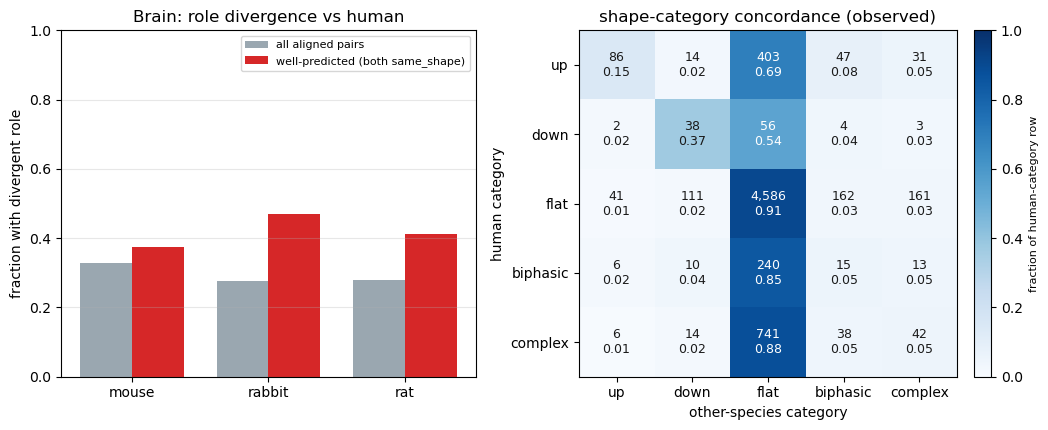

In [48]:
if len(comp):
    g = comp.groupby("species")
    summary = pd.DataFrame({
        "n_pairs":              g.size(),
        "median_aln_dist":      g["aln_dist"].median(),
        "frac_same_role":       g["same_role"].mean(),
        "frac_divergent":       g["divergent"].mean(),
        "human_frac_well_pred": g["human_same_shape"].mean(),
        "other_frac_well_pred": g["other_same_shape"].mean(),
        "frac_well_predicted":  g["well_predicted"].mean(),
    }).round(3)
    display(summary)

    # shape-category concordance: human category vs other-species category (per category)
    cats = [c for c in CAT_ORDER if c in set(comp["human_cat"]) | set(comp["other_cat"])]
    ct = (pd.crosstab(comp["human_cat"].fillna("none"), comp["other_cat"].fillna("none"))
            .reindex(index=cats, columns=cats, fill_value=0))
    print("Shape-category concordance (rows = human, cols = other species):")
    display(ct)

    fig, (axb, axh) = plt.subplots(1, 2, figsize=(10.6, 4.4), gridspec_kw={"width_ratios": [1, 1]})

    # ── per-species role divergence: all pairs vs well-predicted-only ──
    species = list(summary.index)
    x = np.arange(len(species)); w = 0.38
    wp = comp[comp["well_predicted"]]
    div_all = [comp.loc[comp.species == s, "divergent"].mean() for s in species]
    div_wp  = [wp.loc[wp.species == s, "divergent"].mean() if (wp.species == s).any() else 0.0
               for s in species]
    axb.bar(x - w/2, div_all, w, label="all aligned pairs", color="#9aa7b0")
    axb.bar(x + w/2, div_wp,  w, label="well-predicted (both same_shape)", color="#d62728")
    axb.set_xticks(x); axb.set_xticklabels(species); axb.set_ylim(0, 1)
    axb.set_ylabel("fraction with divergent role"); axb.grid(axis="y", alpha=0.3)
    axb.set_title(f"{FOCUS_TISSUE}: role divergence vs human"); axb.legend(fontsize=8)

    # ── role-concordance heatmap (row-normalised fraction, text = counts) ──
    frac = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0)
    im = axh.imshow(frac.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
    axh.set_xticks(range(len(ct.columns))); axh.set_xticklabels(ct.columns)
    axh.set_yticks(range(len(ct.index)));   axh.set_yticklabels(ct.index)
    axh.set_xlabel("other-species category"); axh.set_ylabel("human category")
    axh.set_title("shape-category concordance (observed)")
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            f = frac.iloc[i, j]
            txt = f"{int(ct.iloc[i, j]):,}\n{f:.2f}" if np.isfinite(f) else f"{int(ct.iloc[i, j]):,}"
            axh.text(j, i, txt, ha="center", va="center", fontsize=9,
                     color="white" if (np.isfinite(f) and f > 0.5) else "#1a1a1a")
    cbar = fig.colorbar(im, ax=axh, fraction=0.046, pad=0.04)
    cbar.set_label("fraction of human-category row", fontsize=8)

    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"role_divergence_concordance_chr{CHROM_TAG}.png"),
                dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No aligned pairs - check ALIGN_TOL / assembly names / shape parquets.")

## 5 — Example trajectories

### 5a — Correctly predicted divergent trajectories

Sites whose observed developmental **role differs** between human and the aligned species, where
the model **reproduces the observed shape in both** (`same_shape`) — so the divergence is real and
well predicted. True (solid) vs predicted (dashed), one panel per species.

In [52]:
from alphagenome_pytorch.plotting.splicing import plot_splice_site_predictions

def _load_all_tissues(sp, positions):
    """All-tissue predictions at the given positions, laid out for plot_splice_site_predictions."""
    posset = {int(x) for x in positions}
    ppath = _pred_path(sp)
    if os.path.exists(ppath):
        try:
            df = pd.read_parquet(ppath, filters=[("Position", "in", list(posset))])
        except Exception:
            df = pd.read_parquet(ppath); df = df[df["Position"].isin(posset)]
        df = df.rename(columns={"true": "SSE_true", "pred": "SSE_pred"})
        if "Species" not in df.columns: df["Species"] = sp
        df["Chromosome"] = df["Chromosome"].astype(str)
        return df
    return None

# divergent role across species, and well predicted (obs shape reproduced) in BOTH species
cand = comp[comp["divergent"] & comp["well_predicted"]].copy()
cand = cand.sort_values(["human_role", "aln_dist"])

# subset only human role flat
# cand = cand[cand['human_role'] == 'flat']

print(f"{cand['human_site'].nunique():,} human sites: divergent role & well-predicted in both species")
display(cand)

220 human sites: divergent role & well-predicted in both species


,human_site,species,aln_site,aln_dist,human_role,human_shape,human_cat,human_same_shape,other_role,other_shape,other_cat,other_same_shape,same_role,divergent,well_predicted
25,1:2519323:-,mouse,4:154971372:+,0,complex,complex,complex,True,flat,flat_high,flat,True,False,True,True
68,1:11082877:-,rat,5:169038034:+,0,complex,complex,complex,True,flat,flat_high,flat,True,False,True,True
69,1:11087447:-,rat,5:169037529:+,0,complex,complex,complex,True,flat,flat_high,flat,True,False,True,True
103,1:25753577:+,rabbit,13:127969463:-,0,complex,complex,complex,True,flat,flat_high,flat,True,False,True,True
113,1:25771656:+,rabbit,13:127958789:-,0,complex,complex,complex,True,flat,flat_high,flat,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6678,9:92403233:-,mouse,13:49609356:+,0,flat,flat_high,flat,True,dynamic,down-up,biphasic,True,False,True,True
575,1:161176612:-,mouse,1:171271202:+,1,flat,flat_low,flat,True,dynamic,down-up,biphasic,True,False,True,True
1187,10:12107911:+,mouse,2:5910407:-,3,flat,flat_low,flat,True,complex,complex,complex,True,False,True,True
1707,11:654047:-,mouse,7:141301688:-,3,flat,flat_low,flat,True,dynamic,down-up,biphasic,True,False,True,True


In [53]:
cand.value_counts(["human_role", "other_role"], dropna=False)

human_role  other_role
complex     flat          177
dynamic     flat           73
flat        dynamic         7
            complex         4
complex     dynamic         3
dynamic     complex         1
Name: count, dtype: int64

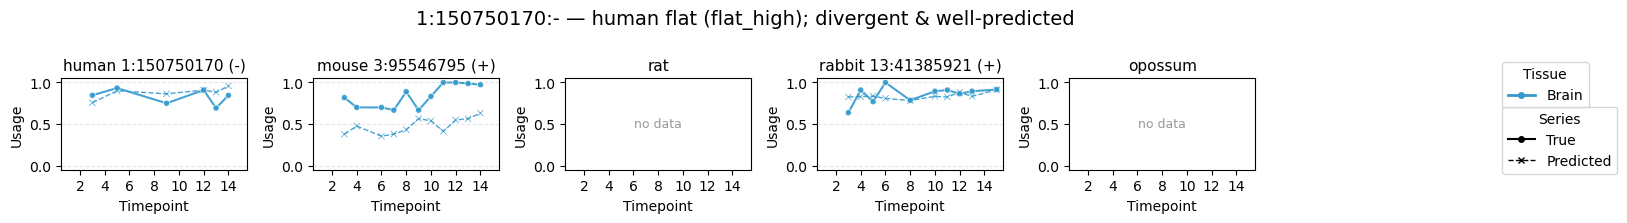

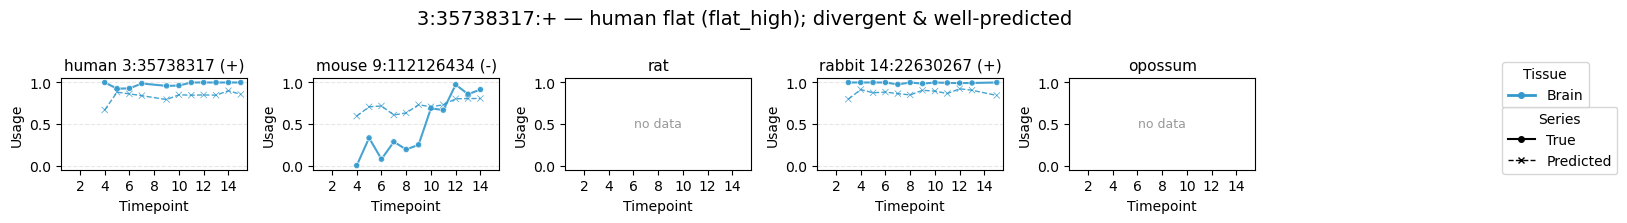

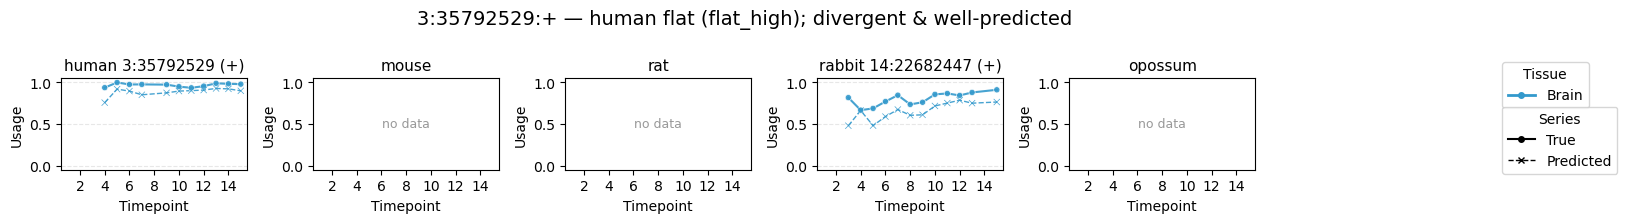

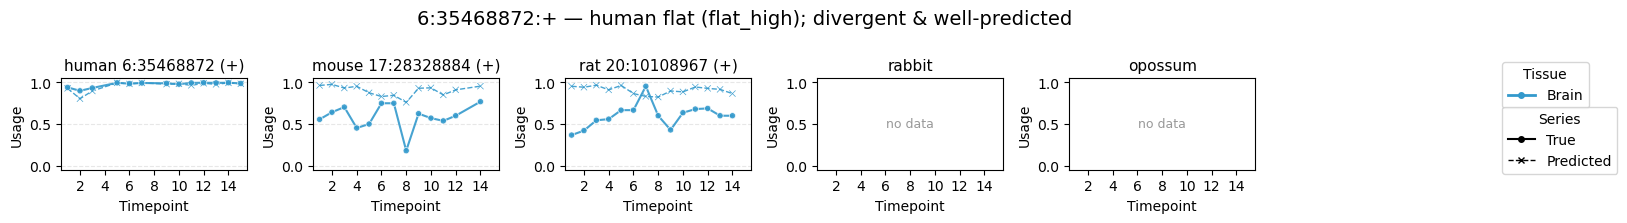

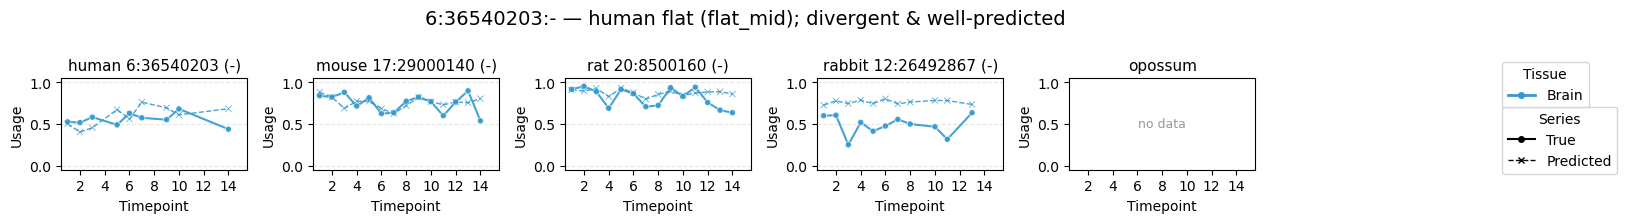

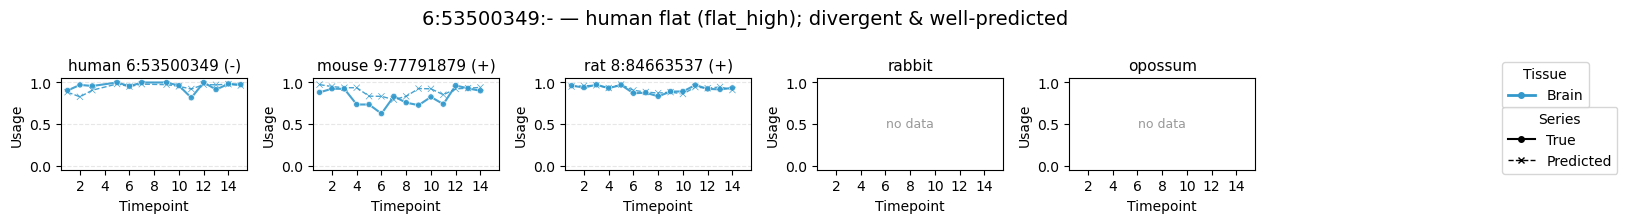

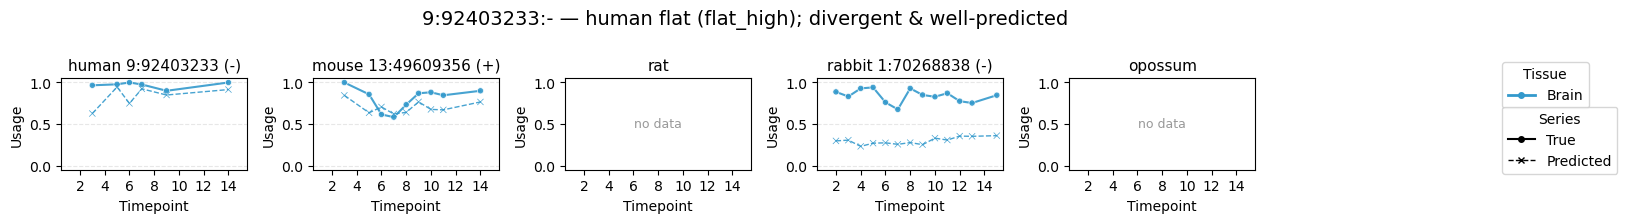

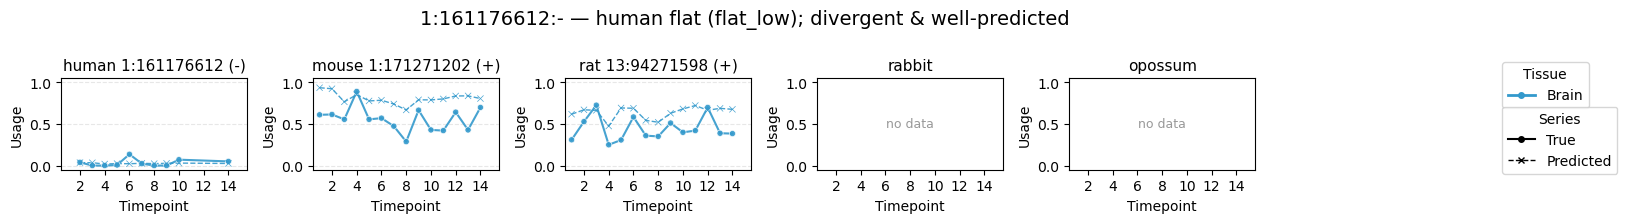

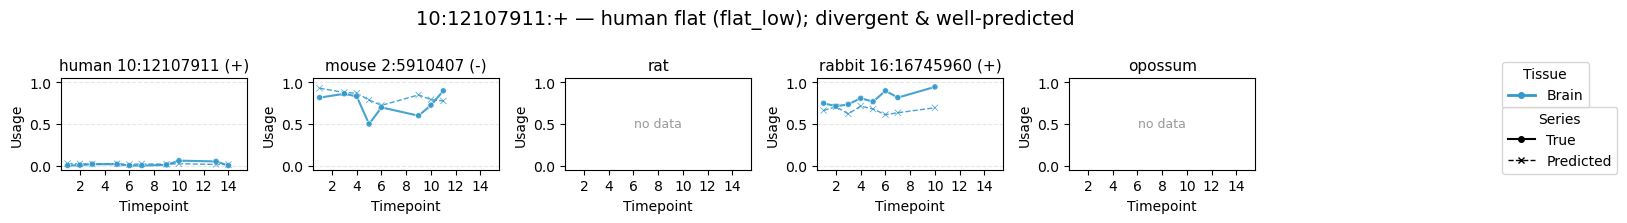

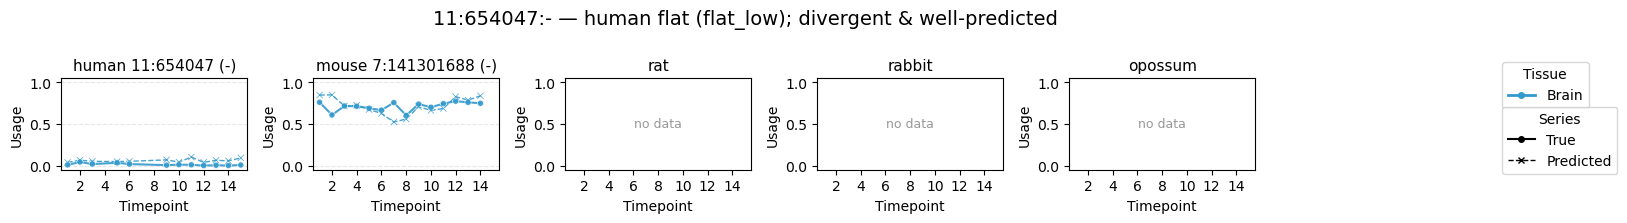

In [51]:
from alphagenome_pytorch.plotting.splicing import plot_splice_site_predictions
N_PLOT = 10

top = cand.drop_duplicates("human_site").head(N_PLOT)
for _, r in top.iterrows():
    hsite = r["human_site"]
    hchrom = sx.parse_site(hsite)[0]
    frames, coords = [], []
    hf = _load_all_tissues("human", [sx.parse_site(hsite)[1]])
    if hf is not None: frames.append(hf)
    coords.append(f"human {hsite}")                     # human column always present
    for sp in OTHER_SPECIES:                            # one fixed column per species
        rec = records[hsite].get(sp)
        added = False
        if rec:
            ap = sx.parse_site(rec["aln_site"])[1]
            f = _load_all_tissues(sp, [ap])
            if f is not None and not f.empty:
                frames.append(f); coords.append(f"{sp} {rec['aln_site']}"); added = True
        if not added:
            coords.append(f"{sp} {hchrom}:0")           # placeholder -> empty panel
    fig = plot_splice_site_predictions(
        pd.concat(frames, ignore_index=True), site_coords=coords,
        true_col="SSE_true", pred_col="SSE_pred",
        tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER,
        tissue_subset=[FOCUS_TISSUE], n_cols=len(coords), split_by_tissue=False, show_missing=True,
        title=f"{hsite} — human {r['human_role']} ({r['human_shape']}); divergent & well-predicted",
    )
    if fig is not None:
        for ax in fig.axes: ax.set_ylim(-0.05, 1.05)
        fig.savefig(os.path.join(OUT_DIR, f"aligned_{hsite.replace(':', '_')}.png"),
                    dpi=200, bbox_inches="tight")
        plt.show()

### 5b — Divergent but not well-predicted

Same divergent-role sites, but where the model **fails to reproduce the observed shape** in at
least one species (`same_shape` False) — here the apparent cross-species divergence may be a
prediction artifact rather than real biology.

In [ ]:
# divergent role across species, but NOT well predicted (>=1 species' shape mispredicted)
mis = comp[comp["divergent"] & ~comp["well_predicted"]].copy()
mis = mis.sort_values(["human_role", "aln_dist"])
print(f"{mis['human_site'].nunique():,} human sites: divergent role but mispredicted in >=1 species")

top_mis = mis.drop_duplicates("human_site").head(N_PLOT)
for _, r in top_mis.iterrows():
    hsite = r["human_site"]
    hchrom = sx.parse_site(hsite)[0]
    frames, coords = [], []
    hf = _load_all_tissues("human", [sx.parse_site(hsite)[1]])
    if hf is not None: frames.append(hf)
    coords.append(f"human {hsite}")                     # human column always present
    for sp in OTHER_SPECIES:                            # one fixed column per species
        rec = records[hsite].get(sp)
        added = False
        if rec:
            ap = sx.parse_site(rec["aln_site"])[1]
            f = _load_all_tissues(sp, [ap])
            if f is not None and not f.empty:
                frames.append(f); coords.append(f"{sp} {rec['aln_site']}"); added = True
        if not added:
            coords.append(f"{sp} {hchrom}:0")           # placeholder -> empty panel
    fig = plot_splice_site_predictions(
        pd.concat(frames, ignore_index=True), site_coords=coords,
        true_col="SSE_true", pred_col="SSE_pred",
        tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER,
        tissue_subset=[FOCUS_TISSUE], n_cols=len(coords), split_by_tissue=False, show_missing=True,
        title=f"{hsite} — human {r['human_role']} ({r['human_shape']}); divergent, NOT well-predicted",
    )
    if fig is not None:
        for ax in fig.axes: ax.set_ylim(-0.05, 1.05)
        fig.savefig(os.path.join(OUT_DIR, f"mispred_{hsite.replace(':', '_')}.png"),
                    dpi=200, bbox_inches="tight")
        plt.show()

### 5c — Directed shape differences (e.g. up in human, flat in other)

Pick a human category and an other-species category and list / plot the sites where the observed
shapes differ *in that specific direction*, restricted (by default) to pairs the model predicts
well in both species (`same_shape`). The category crosstab above (§4) shows the counts for every
direction; this drills into one.

In [ ]:
HUMAN_CAT       = "up"      # up / down / flat / biphasic / complex
OTHER_CAT       = "flat"
WELL_PRED_ONLY  = True       # keep only pairs predicted well (same_shape) in BOTH species
N_PLOT          = 8

def difference_pairs(human_cat, other_cat, well_pred=WELL_PRED_ONLY, species=None):
    sub = comp[(comp["human_cat"] == human_cat) & (comp["other_cat"] == other_cat)].copy()
    if well_pred: sub = sub[sub["well_predicted"]]
    if species:   sub = sub[sub["species"] == species]
    return sub

def show_difference(human_cat=HUMAN_CAT, other_cat=OTHER_CAT, well_pred=WELL_PRED_ONLY,
                    species=None, n=N_PLOT):
    sub = difference_pairs(human_cat, other_cat, well_pred, species)
    tag = f"human {human_cat} -> other {other_cat}" + (" [well-predicted]" if well_pred else "")
    print(f"{tag}: {len(sub):,} pairs across {sub['human_site'].nunique():,} human sites")
    if not len(sub):
        print("  (none)"); return sub
    print("  by species:", sub["species"].value_counts().to_dict())
    top_shapes = (sub.groupby(["human_shape", "other_shape"]).size()
                     .sort_values(ascending=False).head(8))
    print("  top (human_shape -> other_shape):")
    for (hs, os_), n_ in top_shapes.items():
        print(f"    {hs:>14} -> {os_:<14} {n_:,}")

    for hsite in sub.drop_duplicates("human_site").head(n)["human_site"]:
        hits = sub.loc[sub["human_site"] == hsite, "species"].tolist()
        hchrom = sx.parse_site(hsite)[0]
        frames, coords = [], []
        hf = _load_all_tissues("human", [sx.parse_site(hsite)[1]])
        if hf is not None: frames.append(hf)
        coords.append(f"human {hsite}")
        for sp in OTHER_SPECIES:
            rec = records[hsite].get(sp); added = False
            if rec:
                ap = sx.parse_site(rec["aln_site"])[1]
                f = _load_all_tissues(sp, [ap])
                if f is not None and not f.empty:
                    frames.append(f); coords.append(f"{sp} {rec['aln_site']}"); added = True
            if not added:
                coords.append(f"{sp} {hchrom}:0")
        r0 = sub[sub["human_site"] == hsite].iloc[0]
        fig = plot_splice_site_predictions(
            pd.concat(frames, ignore_index=True), site_coords=coords,
            true_col="SSE_true", pred_col="SSE_pred",
            tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER,
            tissue_subset=[FOCUS_TISSUE], n_cols=len(coords), split_by_tissue=False, show_missing=True,
            title=f"{hsite}: human {human_cat} ({r0['human_shape']}) -> {other_cat} in {', '.join(hits)}")
        if fig is not None:
            for ax in fig.axes: ax.set_ylim(-0.05, 1.05)
            fig.savefig(os.path.join(OUT_DIR,
                        f"diff_{human_cat}_vs_{other_cat}_{hsite.replace(':', '_')}.png"),
                        dpi=200, bbox_inches="tight")
            plt.show()
    return sub

_ = show_difference()


## 6 — Inspect one human site across all aligned species

For a chosen human site, plot the true (solid) and predicted (dashed) `FOCUS_TISSUE` trajectory
for the human site and its aligned counterpart in every other species. A species panel is left
**empty with the reason** when:
- **no alignment** — the MAF has no aligned base for that species at this human site;
- **aligned, no splice site** — there is an aligned base but no predicted/observed splice site
  within `ALIGN_TOL` bp of it;
- **no predictions** — the species has no prediction file.

In [9]:
from alphagenome_pytorch.plotting.splicing import plot_splice_site_predictions

def _nearest_pos(sorted_pos, pos, tol):
    if len(sorted_pos) == 0: return None
    j = bisect.bisect_left(sorted_pos, pos)
    cand = [sorted_pos[k] for k in (j - 1, j) if 0 <= k < len(sorted_pos)]
    if not cand: return None
    best = min(cand, key=lambda x: abs(x - pos))
    return int(best) if abs(best - pos) <= tol else None

def _species_site(sp, hsite, tol=ALIGN_TOL, tissue=FOCUS_TISSUE):
    """Resolve the site to plot for `sp`: (status, chrom, pos).
    status in {'ok','no_alignment','no_splice_site','no_predictions'}."""
    row = lift_df[(lift_df["species"] == sp) & (lift_df["human_site"] == hsite)]
    if row.empty:
        return "no_alignment", None, None
    chrom, apos = str(row.iloc[0]["aln_chrom"]), int(row.iloc[0]["aln_pos"])
    win = list(range(apos - tol, apos + tol + 1))
    pr = load_predictions(sp, tissue, positions=win)
    if pr is None:
        return "no_predictions", chrom, apos
    pr = pr[pr["Chromosome"] == chrom]
    if pr.empty:
        return "no_splice_site", chrom, apos
    snapped = _nearest_pos(np.sort(pr["Position"].astype(int).unique()), apos, tol)
    if snapped is None:
        return "no_splice_site", chrom, apos
    return "ok", chrom, snapped

def _load_all_tissues(sp, chrom, pos):
    """All-tissue predictions at one site, laid out for plot_splice_site_predictions."""
    ppath = _pred_path(sp)
    if not os.path.exists(ppath):
        return None
    try:
        df = pd.read_parquet(ppath, filters=[("Position", "==", int(pos))])
    except Exception:
        df = pd.read_parquet(ppath); df = df[df["Position"] == int(pos)]
    df = df[df["Chromosome"].astype(str) == str(chrom)].rename(
        columns={"true": "SSE_true", "pred": "SSE_pred"})
    if "Species" not in df.columns:
        df["Species"] = sp
    df["Chromosome"] = df["Chromosome"].astype(str)
    return df if not df.empty else None

def inspect_aligned_site(site, tol=ALIGN_TOL, tissue=FOCUS_TISSUE):
    """Plot true/pred FOCUS_TISSUE trajectories (via plot_splice_site_predictions) for the
    human site + every species with an aligned splice site; report the reason for the rest."""
    parts = str(site).split(":")
    chrom, pos = (CHROMS[0], int(parts[0])) if len(parts) == 1 else (parts[0], int(parts[1]))
    hsite = sx.ensure_site_strand(f"{chrom}:{pos}", sx.strand_series(USAGE_TMPL, "human"))
    REASON = {"no_alignment": "no alignment",
              "no_splice_site": f"aligned but no predicted splice site within +/-{tol} bp",
              "no_predictions": "no predictions for species",
              "no_data": "no usage/prediction rows at site"}

    frames, coords, reasons = [], [], {}
    for sp in ["human"] + OTHER_SPECIES:
        if sp == "human":
            status, c, ppos = "ok", chrom, pos
        else:
            status, c, ppos = _species_site(sp, hsite, tol, tissue)
        if status != "ok":
            reasons[sp] = REASON[status]; continue
        df = _load_all_tissues(sp, c, ppos)
        if df is None:
            reasons[sp] = REASON["no_data"]; continue
        frames.append(df)
        aln = f"  (Δ{abs(ppos - int(lift_df[(lift_df.species==sp)&(lift_df.human_site==hsite)].iloc[0].aln_pos))}bp)" if sp != "human" else ""
        coords.append(f"{sp} {c}:{ppos}")

    print(f"human {hsite}  |  {tissue}")
    for sp in ["human"] + OTHER_SPECIES:
        print(f"  {sp:8s}: {'plotted' if sp not in reasons else reasons[sp]}")

    if not frames:
        print("Nothing to plot."); return None
    fig = plot_splice_site_predictions(
        pd.concat(frames, ignore_index=True), site_coords=coords,
        true_col="SSE_true", pred_col="SSE_pred",
        tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER, tissue_subset=[tissue],
        n_cols=len(coords), split_by_tissue=False,
        title=f"human {hsite}"
    )
    if fig is not None:
        for ax in fig.axes: ax.set_ylim(-0.05, 1.05)
        fig.savefig(os.path.join(OUT_DIR,
                    f"aligned_site_{hsite.replace(':', '_')}_{tissue.lower()}.png"),
                    dpi=200, bbox_inches="tight")
        plt.show()
    return fig

human 8:130160784  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : aligned but no predicted splice site within +/-10 bp
  rabbit  : aligned but no predicted splice site within +/-10 bp
  opossum : aligned but no predicted splice site within +/-10 bp


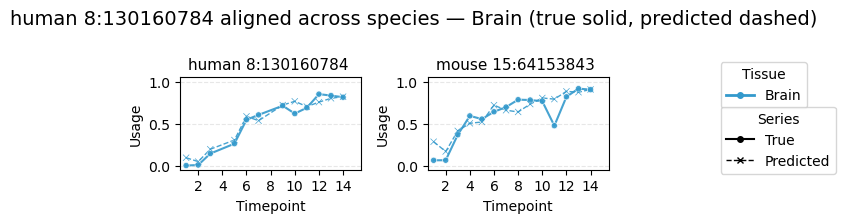

In [32]:
SITE = "8:130160784"
_ = inspect_aligned_site(SITE, tol=10)

human 3:170907641  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


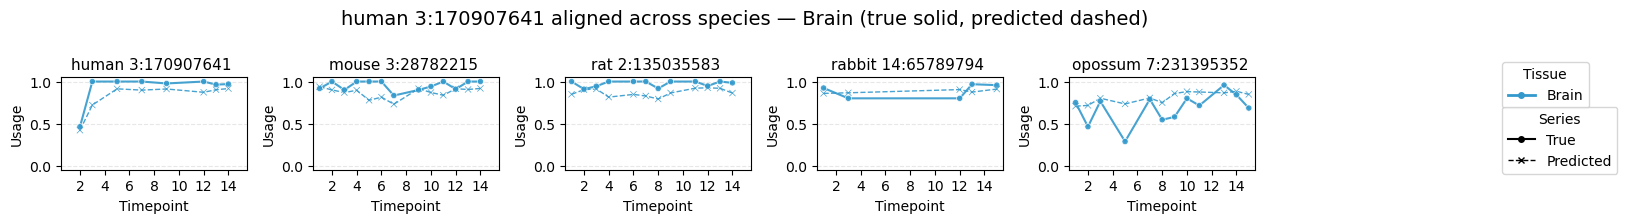

In [33]:
SITE = "3:170907641"
_ = inspect_aligned_site(SITE)

human 1:174800499:+  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : aligned but no predicted splice site within +/-3 bp


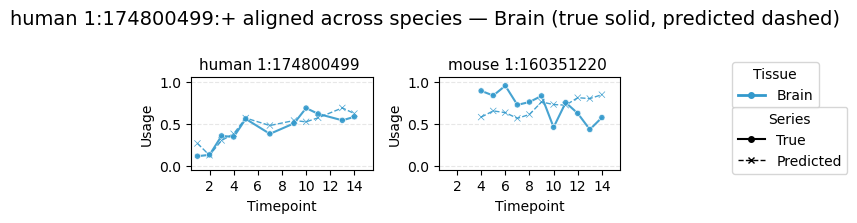

In [70]:
SITE = "1:174800499"
_ = inspect_aligned_site(SITE)

human 1:232404177:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


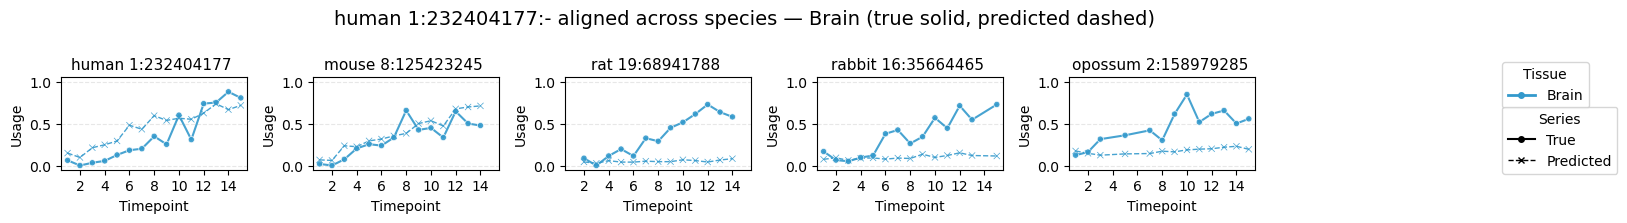

In [71]:
SITE = "1:232404177"
_ = inspect_aligned_site(SITE)

human 9:14120439:-  |  Cerebellum
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


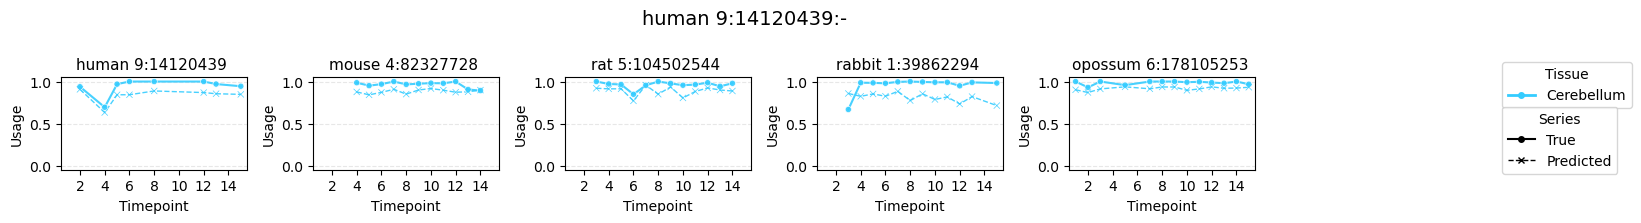

In [18]:
SITE = "9:14120439"
_ = inspect_aligned_site(SITE, tissue="Cerebellum")

human 9:14120623:-  |  Cerebellum
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : aligned but no predicted splice site within +/-3 bp


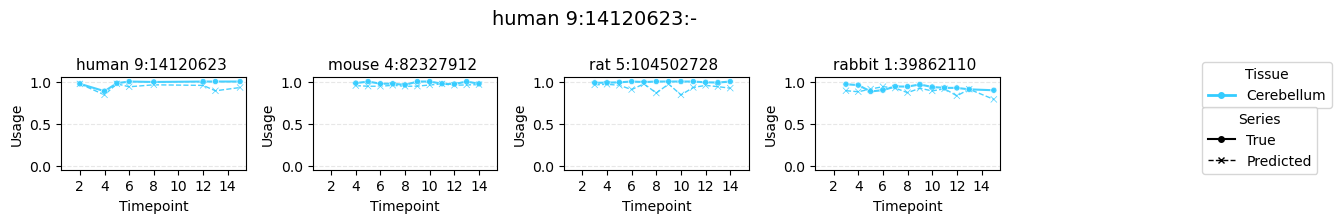

In [19]:
SITE = "9:14120623"
_ = inspect_aligned_site(SITE, tissue="Cerebellum")

human 10:21173764:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : aligned but no predicted splice site within +/-3 bp


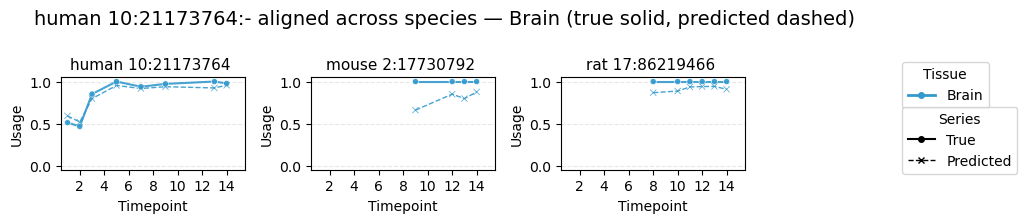

In [74]:
SITE = "10:21173764"
_ = inspect_aligned_site(SITE)

human 10:73396043:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : plotted
  opossum : aligned but no predicted splice site within +/-3 bp


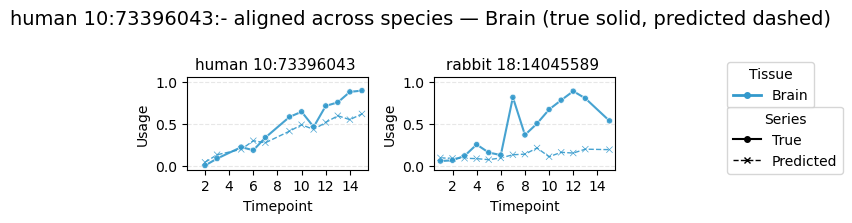

In [72]:
SITE = "10:73396043"
_ = inspect_aligned_site(SITE)

## 7 — Inspect all trajectories for a gene across all aligned species

Specify a **gene** (Ensembl `gene_id` or `gene_name`); the gene span is looked up in the human
GTF-derived gene model, every predicted splice site within that span is collected, and for each
site the aligned splice sites in the other species are resolved and plotted with
`plot_splice_site_predictions` (human + aligned species, `FOCUS_TISSUE`, true solid / predicted
dashed). One figure per splice site (via §6's `inspect_aligned_site`).

In [16]:
# Human GTF-derived gene model (Chromosome / Feature / Start / End / Strand / gene_id / gene_name)
HUMAN_GENE_MODEL = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/Homo_sapiens.parquet"

_gene_tbl_cache = {}
def _human_gene_table():
    if "df" not in _gene_tbl_cache:
        g = pd.read_parquet(HUMAN_GENE_MODEL,
                            columns=["Chromosome", "Feature", "Start", "End", "Strand",
                                     "gene_id", "gene_name"])
        _gene_tbl_cache["df"] = g[g["Feature"] == "gene"].copy()
    return _gene_tbl_cache["df"]

def gene_span(gene):
    """Resolve an Ensembl gene_id or gene_name -> (chrom, start, end, strand, gene_id, gene_name)."""
    g = _human_gene_table()
    hit = g[g["gene_id"] == gene]
    if hit.empty:
        hit = g[g["gene_name"].astype(str).str.lower() == str(gene).lower()]
    if hit.empty:
        raise ValueError(f"gene {gene!r} not found in {HUMAN_GENE_MODEL}")
    r = hit.iloc[0]
    return (str(r["Chromosome"]), int(r["Start"]), int(r["End"]),
            r["Strand"], r["gene_id"], r["gene_name"])

def gene_splice_sites(chrom, start, end):
    """Human predicted splice-site positions within [start, end] on `chrom`."""
    ppath = _pred_path("human")
    try:
        s = pd.read_parquet(ppath, columns=["Chromosome", "Position"],
                            filters=[("Chromosome", "==", str(chrom)),
                                     ("Position", ">=", int(start)), ("Position", "<=", int(end))])
    except Exception:
        s = pd.read_parquet(ppath, columns=["Chromosome", "Position"])
        s = s[(s["Chromosome"].astype(str) == str(chrom)) &
              (s["Position"] >= start) & (s["Position"] <= end)]
    return sorted(s["Position"].astype(int).unique().tolist())

def inspect_gene(gene, tissue=FOCUS_TISSUE, tol=ALIGN_TOL):
    """Find a gene's predicted splice sites and plot each one's true/pred trajectories in
    human + every aligned species (reusing §6's `inspect_aligned_site`)."""
    chrom, start, end, strand, gid, gname = gene_span(gene)
    sites = gene_splice_sites(chrom, start, end)
    print(f"{gname} ({gid})  chr{chrom}:{start:,}-{end:,} ({strand})  "
          f"— {len(sites):,} predicted splice site(s), {tissue}")
    if chrom not in CHROMS:
        print(f"  NOTE: chr{chrom} not in CHROMS={CHROMS}; run §1-§3 with this chromosome "
              f"included so its alignments/lift-over are available.")
    figs = []
    for pos in sites:
        print("-" * 72)
        fig = inspect_aligned_site(f"{chrom}:{pos}", tol=tol, tissue=tissue)
        if fig is not None:
            figs.append(fig)
    print("=" * 72)
    print(f"Plotted {len(figs)} / {len(sites)} sites (rest had no data / no aligned splice site).")
    return figs


NFIB (ENSG00000147862)  chr9:14,081,842-14,398,983 (-)  — 35 predicted splice site(s), Brain
------------------------------------------------------------------------
human 9:14088325:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


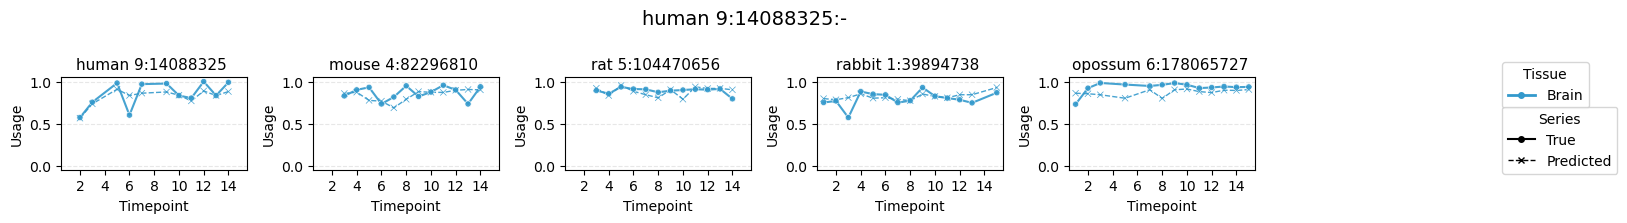

------------------------------------------------------------------------
human 9:14093459:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : no alignment


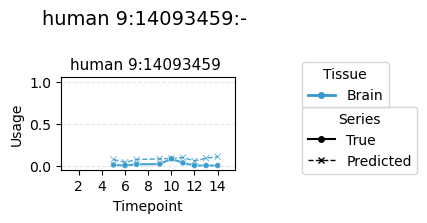

------------------------------------------------------------------------
human 9:14093463:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : no alignment


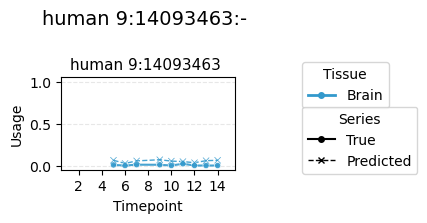

------------------------------------------------------------------------
human 9:14094461:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : aligned but no predicted splice site within +/-3 bp


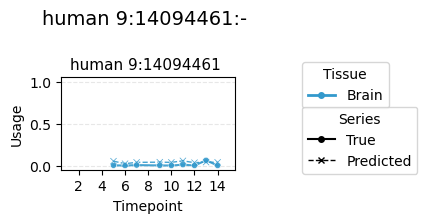

------------------------------------------------------------------------
human 9:14096350:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : aligned but no predicted splice site within +/-3 bp


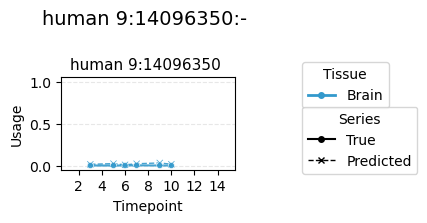

------------------------------------------------------------------------
human 9:14102421:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : aligned but no predicted splice site within +/-3 bp


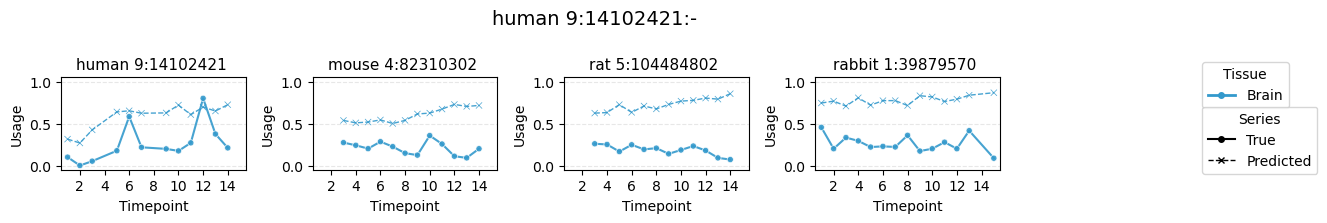

------------------------------------------------------------------------
human 9:14102509:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : aligned but no predicted splice site within +/-3 bp


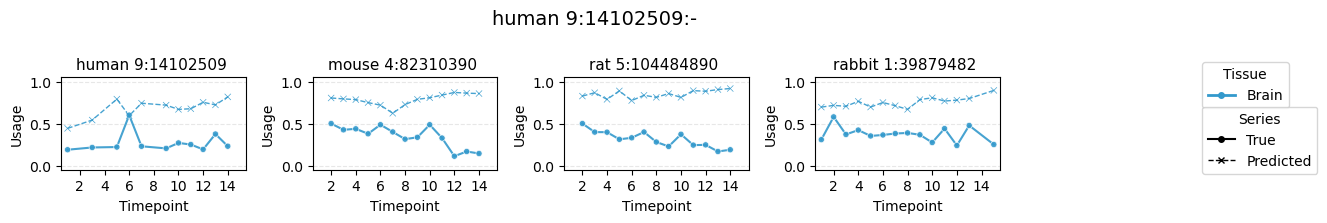

------------------------------------------------------------------------
human 9:14112998:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


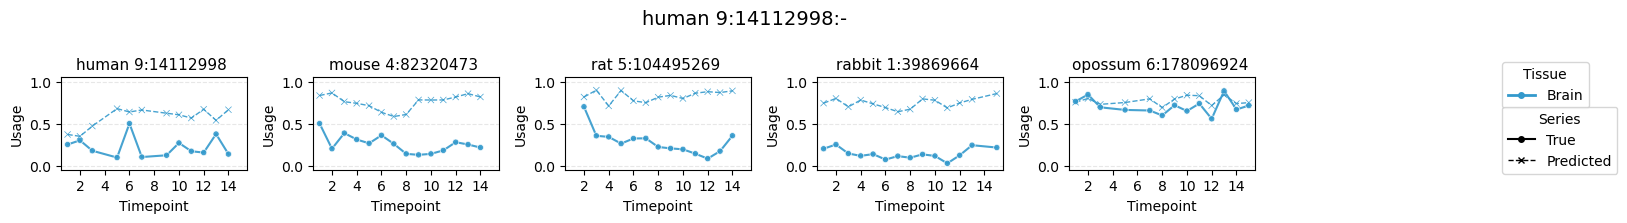

------------------------------------------------------------------------
human 9:14113080:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


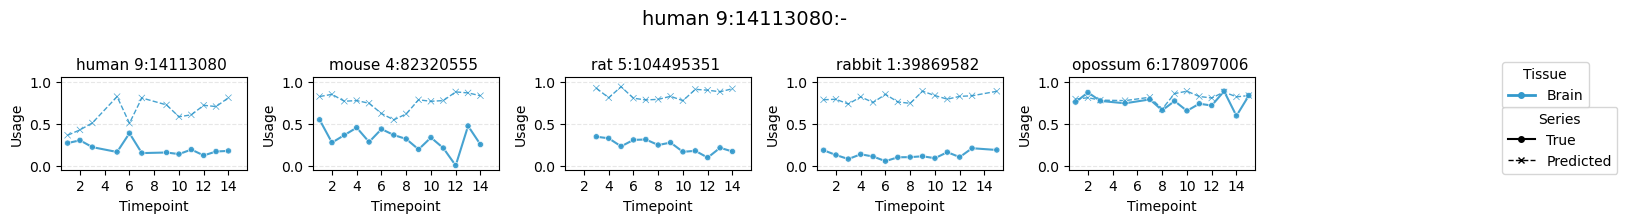

------------------------------------------------------------------------
human 9:14116180:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : aligned but no predicted splice site within +/-3 bp


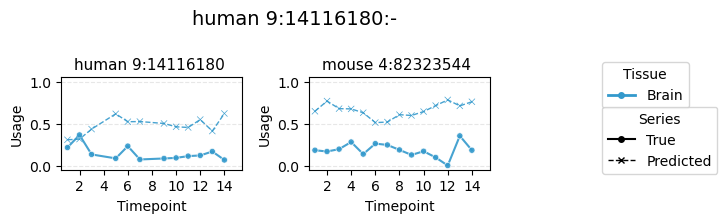

------------------------------------------------------------------------
human 9:14116207:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


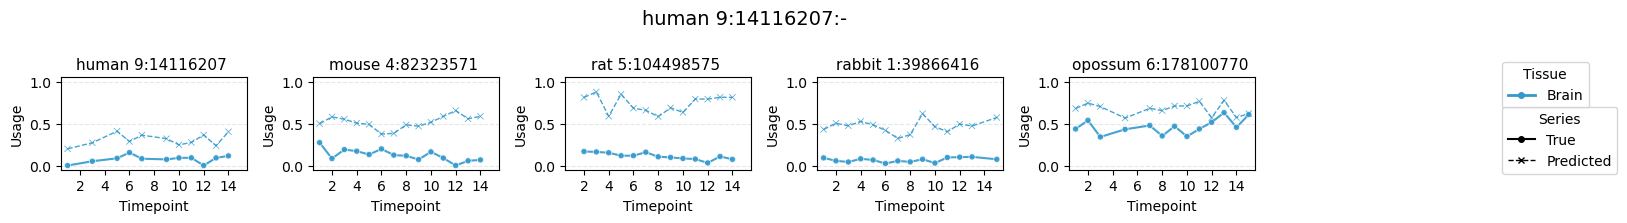

------------------------------------------------------------------------
human 9:14116345:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


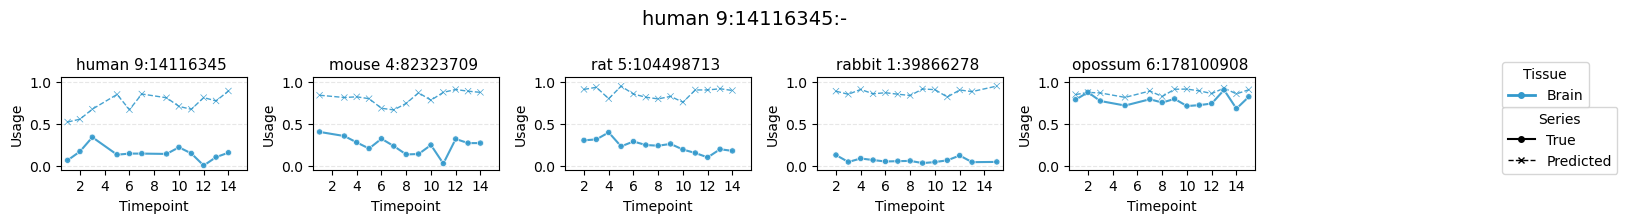

------------------------------------------------------------------------
human 9:14120439:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


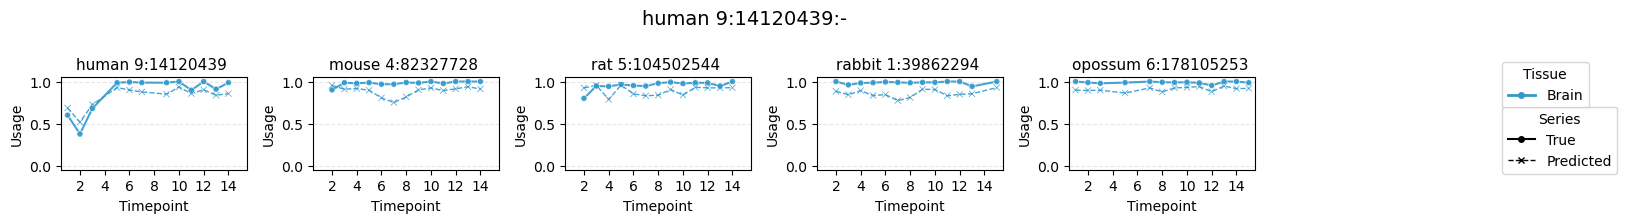

------------------------------------------------------------------------
human 9:14120623:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : aligned but no predicted splice site within +/-3 bp


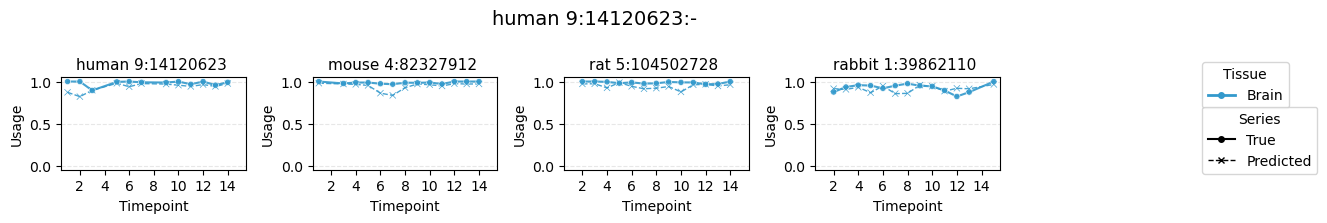

------------------------------------------------------------------------
human 9:14125631:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : aligned but no predicted splice site within +/-3 bp


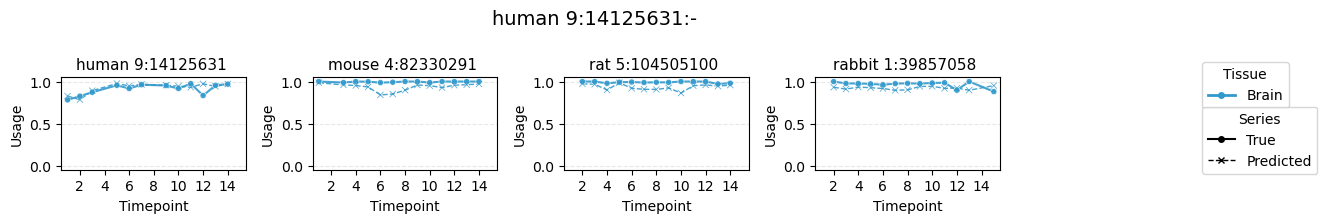

------------------------------------------------------------------------
human 9:14125634:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : aligned but no predicted splice site within +/-3 bp


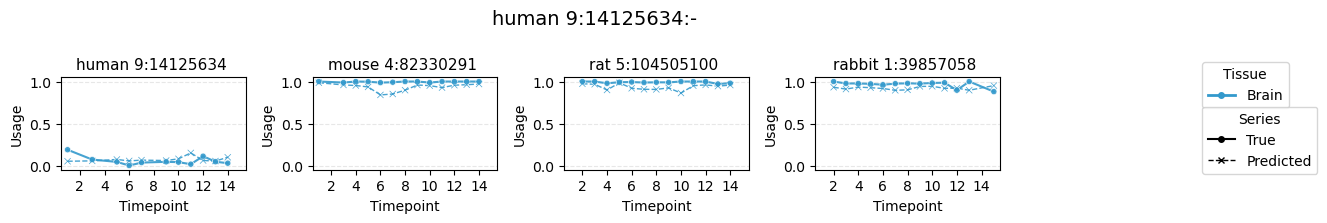

------------------------------------------------------------------------
human 9:14125765:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


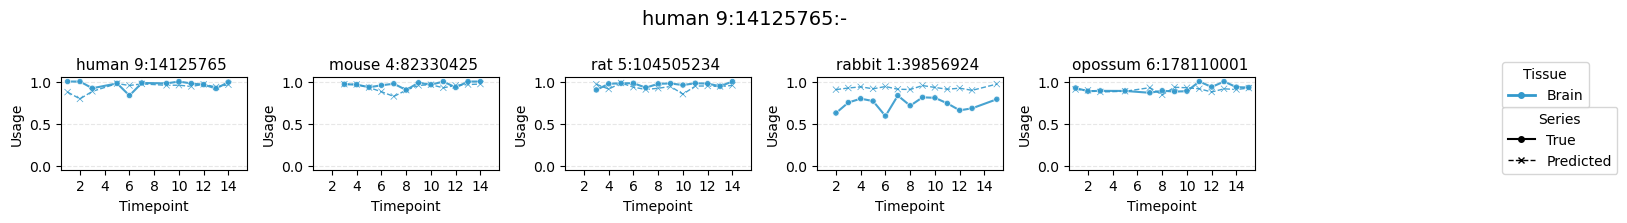

------------------------------------------------------------------------
human 9:14146688:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


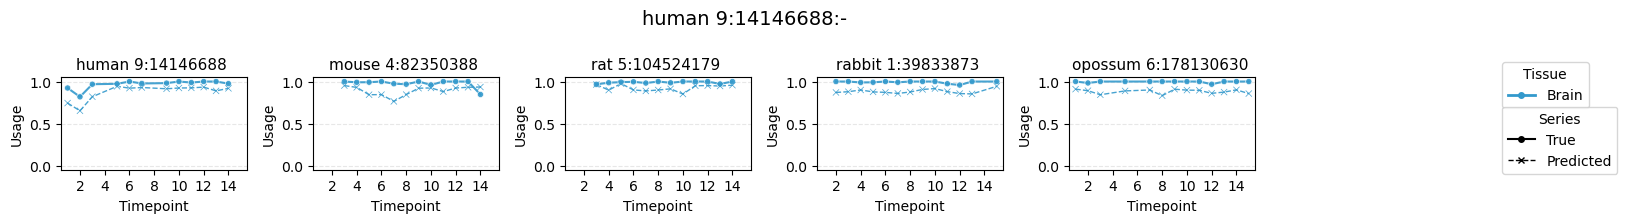

------------------------------------------------------------------------
human 9:14146806:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


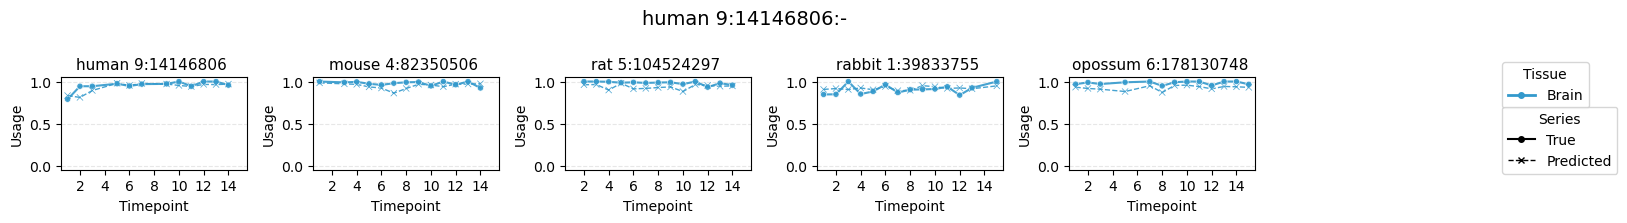

------------------------------------------------------------------------
human 9:14150144:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


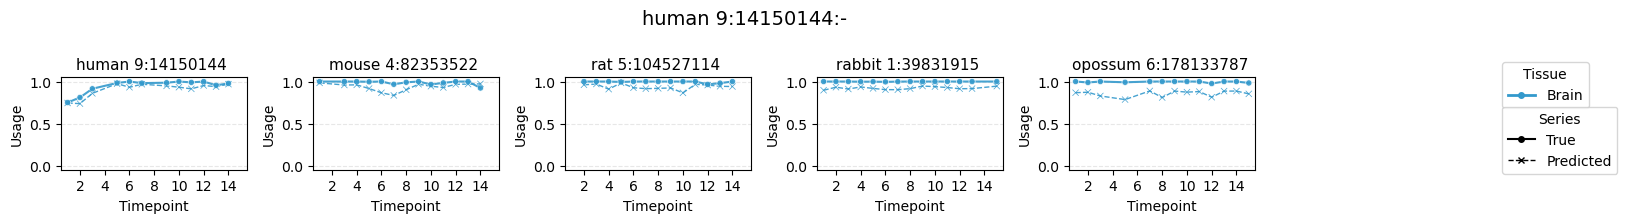

------------------------------------------------------------------------
human 9:14150264:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


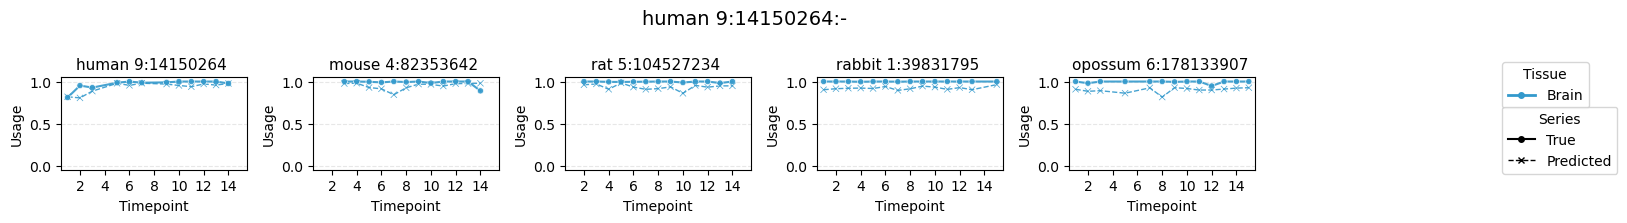

------------------------------------------------------------------------
human 9:14155824:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


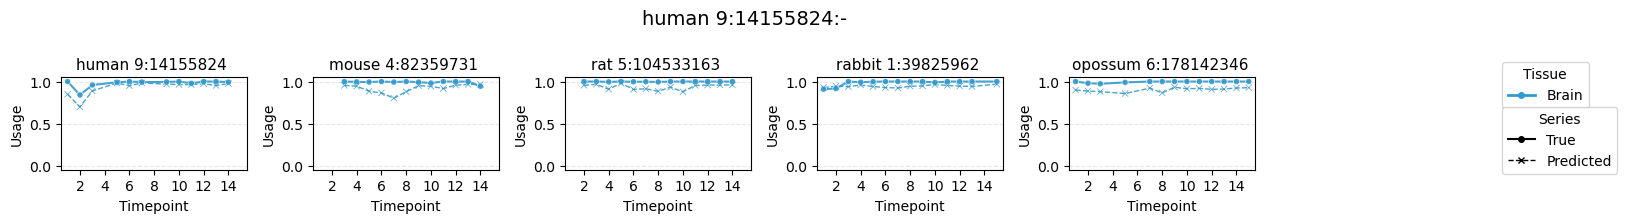

------------------------------------------------------------------------
human 9:14155892:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


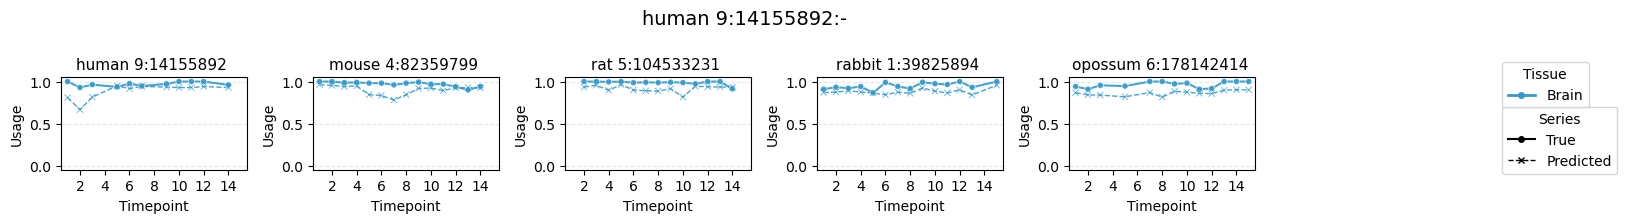

------------------------------------------------------------------------
human 9:14179726:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


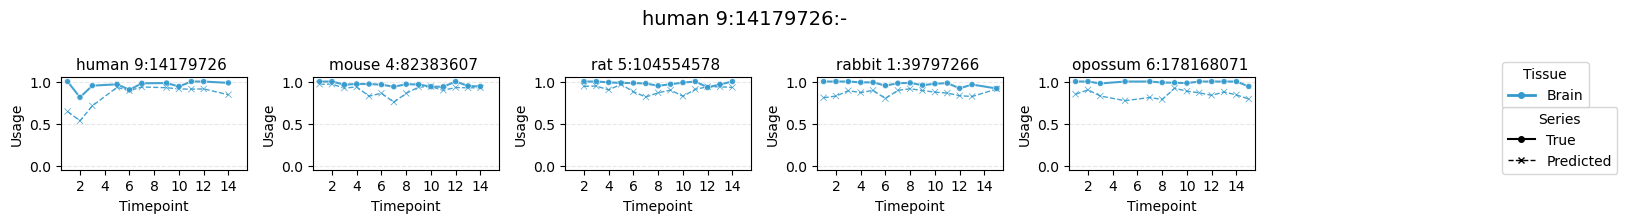

------------------------------------------------------------------------
human 9:14179779:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


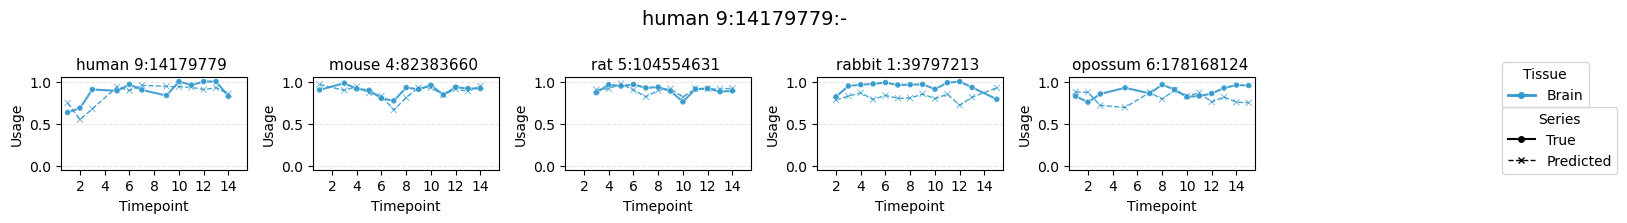

------------------------------------------------------------------------
human 9:14180658:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : no alignment


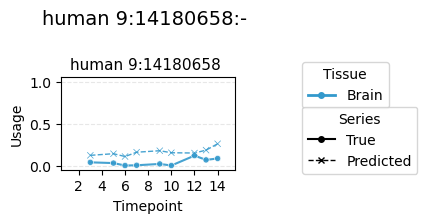

------------------------------------------------------------------------
human 9:14306988:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


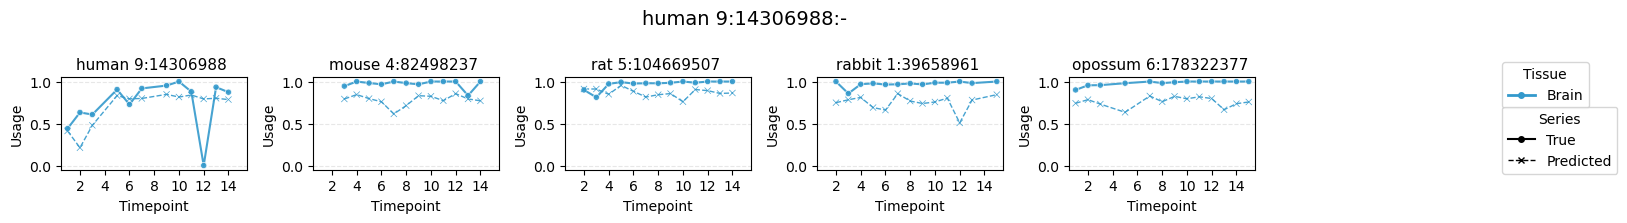

------------------------------------------------------------------------
human 9:14307213:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : aligned but no predicted splice site within +/-3 bp


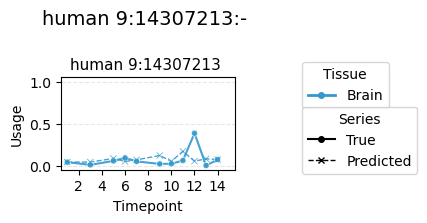

------------------------------------------------------------------------
human 9:14307519:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : plotted
  opossum : plotted


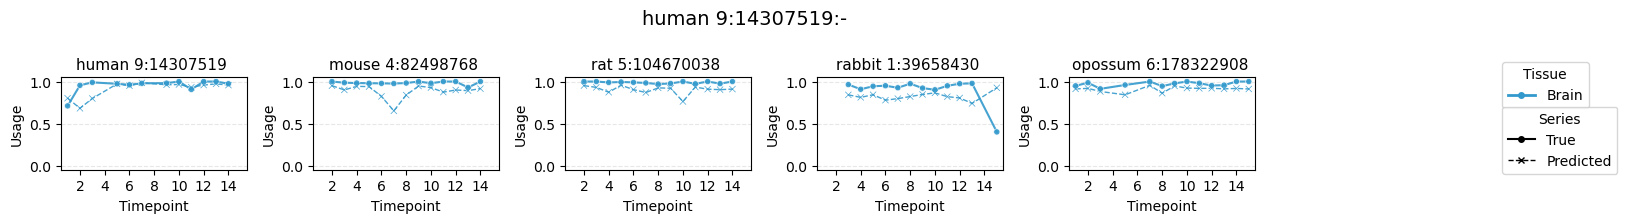

------------------------------------------------------------------------
human 9:14307907:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : aligned but no predicted splice site within +/-3 bp


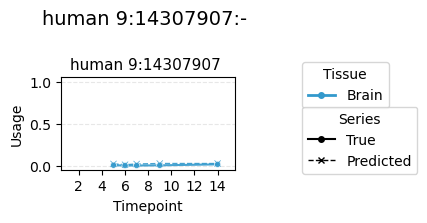

------------------------------------------------------------------------
human 9:14307919:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : aligned but no predicted splice site within +/-3 bp


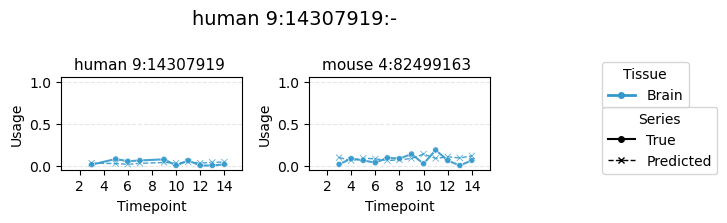

------------------------------------------------------------------------
human 9:14313481:-  |  Brain
  human   : plotted
  mouse   : plotted
  rat     : plotted
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : plotted


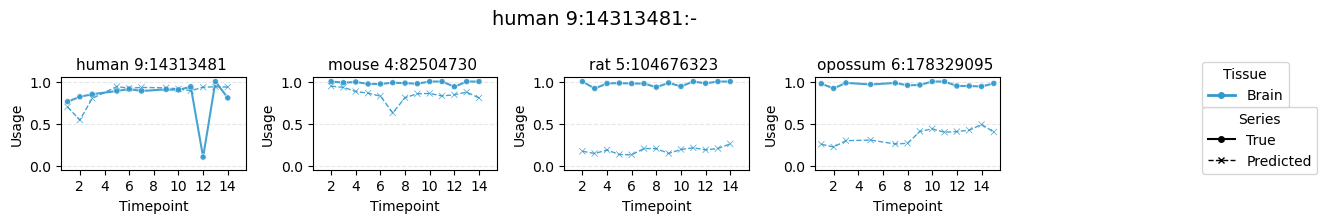

------------------------------------------------------------------------
human 9:14314858:-  |  Brain
  human   : plotted
  mouse   : no alignment
  rat     : no alignment
  rabbit  : no alignment
  opossum : aligned but no predicted splice site within +/-3 bp


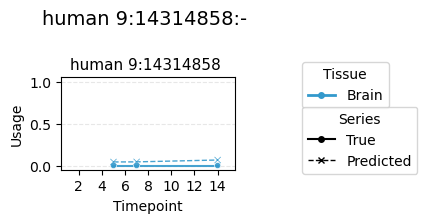

------------------------------------------------------------------------
human 9:14321940:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : plotted
  opossum : aligned but no predicted splice site within +/-3 bp


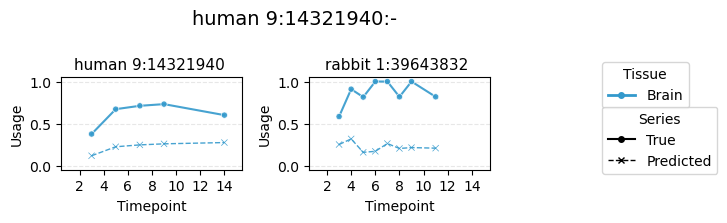

------------------------------------------------------------------------
human 9:14398523:-  |  Brain
  human   : plotted
  mouse   : aligned but no predicted splice site within +/-3 bp
  rat     : aligned but no predicted splice site within +/-3 bp
  rabbit  : aligned but no predicted splice site within +/-3 bp
  opossum : no alignment


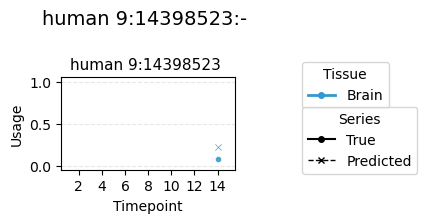

Plotted 35 / 35 sites (rest had no data / no aligned splice site).


In [17]:
GENE = "ENSG00000147862"      # Ensembl gene_id (ENSG...) or gene_name
_ = inspect_gene(GENE)

In [38]:
pq = pd.read_parquet("/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/splice_sites_intersect_usage_protein_coding.parquet")
pq[(pq['Chromosome'] == "1" ) & (pq['Position'] > 109625000) & (pq['Position'] < 109625500)]

,Chromosome,Position,SiteType
34853,1,109625302,Acceptor+
34854,1,109625432,Donor+
